# **Course Requirement Mapping**

## Data Science Requirements Covered:
- Dataset Loading and Exploration
- Data Cleaning (corrupt image removal, size analysis)
- EDA (class distribution, brightness analysis, sample visualization)
- Feature Engineering (augmentation, normalization)
- Model Building with Custom Layer (ChannelAttention)
- Transfer Learning (MobileNetV2)
- Evaluation Metrics (accuracy, loss, confusion matrix, classification report)
- Result Visualization (curves, heatmap, sample predictions)

## Step 1: Setup and Dataset Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

**Uploading Dataset from drive**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Classroom', 'Week 2 Word Lab_1_ICT.gdoc', 'ICT Lab Tasks SEM 1', 'PF lab.Sem 1', 'CV-V1 (3).docx', 'CV-V1 (2).docx', 'CV-V1 (1).docx', 'CV-V1.docx', 'Main.zip', 'Week 7 Power Point (1).gdoc', 'Week 7 Power Point.gdoc', 'Assignment 3 (2).gdoc', 'lab task 10.htm', ' Demo Report.pf.gdoc', 'Library management system', 'SPACE GAME (1).sb3', 'Exercise1.ict.accdb', 'ICT project report.gdoc', 'ICT project report (1).docx', 'ICT project report.docx', '233531_ICT_Project .sb3', '233531 ICT project', '233531 ICT project (1).zip', '233531 ICT project.zip', 'Week 13&14 HTML (7).gdoc', 'Week 13&14 HTML (6).gdoc', 'Week 13&14 HTML (5).gdoc', 'Week 13&14 HTML (4).gdoc', 'Week 13&14 HTML (3).gdoc', 'Week 13&14 HTML (2).gdoc', 'Week 13&14 HTML (1).gdoc', 'Week 13&14 HTML.gdoc', 'English Quiz4.pdf', 'ICT QUIZ.pdf', 'DiscreteStruct.task1.pdf', '233531.DS.task 1.pdf', 'DBMS.lab 3.Q2.drawio', 'SEM 2.OOP', 'Lab 2.gdoc', 'DS.Quiz1.pdf', 'lab6.Q1.cpp', 'Untitled document (2).gdoc', 'DS.Q1.

In [10]:
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)
print("Drive mounted and models folder ready")
print(os.listdir('/content/drive/MyDrive/dataset'))

Drive mounted and models folder ready
['food-101', 'final_dataset']


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Filtering Dataset

In [12]:
import os
import shutil
import random

# paths
SOURCE_DIR = "/content/drive/MyDrive/dataset/food-101/images"
OUTPUT_DIR = "/content/drive/MyDrive/dataset/final_food_dataset"

# how many images per class
IMAGES_PER_CLASS = 500

# automatically get folder names
SELECTED_CLASSES = [
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
]

print("Detected Classes:")
print(SELECTED_CLASSES)

# create filtered dataset
for cls in SELECTED_CLASSES:

    src = os.path.join(SOURCE_DIR, cls)
    dst = os.path.join(OUTPUT_DIR, cls)

    os.makedirs(dst, exist_ok=True)

    # get all images
    all_images = os.listdir(src)

    # shuffle for random selection
    random.shuffle(all_images)

    # limit images
    selected_images = all_images[:IMAGES_PER_CLASS]

    # copy selected images
    for img in selected_images:

        src_path = os.path.join(src, img)
        dst_path = os.path.join(dst, img)

        shutil.copy(src_path, dst_path)

    print(f"{cls}: {len(selected_images)} images copied")

print("\nDataset filtering completed.")

Detected Classes:
['brownie', 'chicken_tikka', 'chai', 'samosa', 'french_fries', 'paratha_roll', 'spaghetti_carbonara', 'chocolate_cake', 'waffles', 'macaroni_and_cheese', 'club_sandwich', 'grilled_cheese_sandwich', 'pizza', 'chicken_curry', 'ice_cream', 'french_toast', 'greek_salad', 'pancakes', 'garlic_bread', 'spring_rolls', 'cup_cakes', 'onion_rings', 'omelette', 'red_velvet_cake', 'lasagna', 'hamburger', 'steak', 'fried_rice', 'chicken_wings', 'hot_and_sour_soup', 'biryani', 'paratha', 'butter_chicken', 'haleem']
brownie: 100 images copied
chicken_tikka: 100 images copied
chai: 100 images copied
samosa: 500 images copied
french_fries: 500 images copied
paratha_roll: 100 images copied
spaghetti_carbonara: 500 images copied
chocolate_cake: 500 images copied
waffles: 500 images copied
macaroni_and_cheese: 500 images copied
club_sandwich: 500 images copied
grilled_cheese_sandwich: 500 images copied
pizza: 500 images copied
chicken_curry: 500 images copied
ice_cream: 500 images copied


Final Dataset

In [13]:
DATASET_DIR = "/content/drive/MyDrive/dataset/final_food_dataset"

## Step 3: Data Cleaning

Checking for corrupt or unreadable images and removing them

In [14]:
from PIL import Image
import os

corrupt = []

for cls in SELECTED_CLASSES:

    folder = os.path.join(OUTPUT_DIR, cls)

    # skip if folder somehow missing
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):

        fpath = os.path.join(folder, fname)

        # skip non-files
        if not os.path.isfile(fpath):
            continue

        try:
            img = Image.open(fpath)
            img.verify()  # verify image integrity

        except Exception:
            corrupt.append(fpath)

            try:
                os.remove(fpath)
            except:
                pass

print(f"Removed {len(corrupt)} corrupt images")

if len(corrupt) > 0:
    print("\nSample corrupt files:")
    print(corrupt[:5])
else:
    print("No corrupt images found.")

Removed 0 corrupt images
No corrupt images found.


Checking image sizes to understand data

In [15]:
import pandas as pd
from PIL import Image
import os

sizes = []

for cls in SELECTED_CLASSES:

    folder = os.path.join(OUTPUT_DIR, cls)

    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):

        fpath = os.path.join(folder, fname)

        if not os.path.isfile(fpath):
            continue

        try:
            img = Image.open(fpath)

            width, height = img.size

            sizes.append({
                "class": cls,
                "width": width,
                "height": height
            })

        except:
            pass

# dataframe
sizes_df = pd.DataFrame(sizes)

# overall statistics
print("Overall Image Size Statistics:")
print(sizes_df[['width', 'height']].describe())

Overall Image Size Statistics:
              width        height
count  13800.000000  13800.000000
mean     496.156884    474.659130
std      137.560908    143.087017
min      168.000000    117.000000
25%      512.000000    384.000000
50%      512.000000    512.000000
75%      512.000000    512.000000
max     4000.000000   4545.000000


## Step 4: EDA (Exploratory Data Analysis)



*   Class Distribution


Class Distribution:

brownie: 100
chicken_tikka: 100
chai: 100
samosa: 500
french_fries: 500
paratha_roll: 100
spaghetti_carbonara: 500
chocolate_cake: 500
waffles: 500
macaroni_and_cheese: 500
club_sandwich: 500
grilled_cheese_sandwich: 500
pizza: 500
chicken_curry: 500
ice_cream: 500
french_toast: 500
greek_salad: 500
pancakes: 500
garlic_bread: 500
spring_rolls: 500
cup_cakes: 500
onion_rings: 500
omelette: 500
red_velvet_cake: 500
lasagna: 500
hamburger: 500
steak: 500
fried_rice: 500
chicken_wings: 500
hot_and_sour_soup: 500
biryani: 100
paratha: 100
butter_chicken: 100
haleem: 100


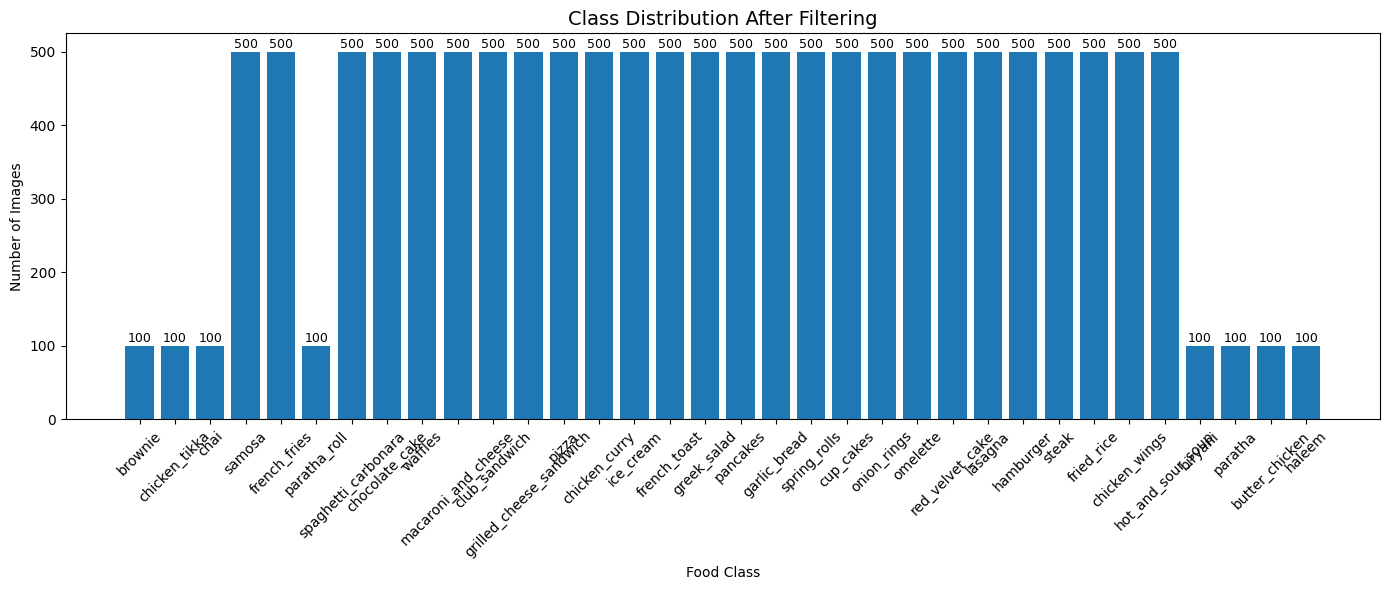

In [16]:
import matplotlib.pyplot as plt
import os

class_counts = {}

for cls in SELECTED_CLASSES:

    folder = os.path.join(OUTPUT_DIR, cls)

    if not os.path.exists(folder):
        continue

    # count only actual image files
    image_files = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]

    class_counts[cls] = len(image_files)

# print counts
print("Class Distribution:\n")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# visualization
plt.figure(figsize=(14, 6))

bars = plt.bar(
    class_counts.keys(),
    class_counts.values()
)

# add value labels on top
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        str(height),
        ha='center',
        fontsize=9
    )

plt.title('Class Distribution After Filtering', fontsize=14)
plt.xlabel('Food Class')
plt.ylabel('Number of Images')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Sample images from each class

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import math
import os

# number of classes
num_classes = len(SELECTED_CLASSES)

# dynamic grid sizing
cols = 5
rows = math.ceil(num_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))

# flatten axes safely
axes = axes.flatten()

for i, cls in enumerate(SELECTED_CLASSES):

    folder = os.path.join(OUTPUT_DIR, cls)

    if not os.path.exists(folder):
        continue

    # only actual files
    images = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]

    if len(images) == 0:
        continue

    # random image
    sample_img = random.choice(images)

    sample_path = os.path.join(folder, sample_img)

    try:
        img = Image.open(sample_path)

        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=11)
        axes[i].axis('off')

    except:
        axes[i].set_title(f"{cls}\nError")
        axes[i].axis('off')

# remove unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images Per Class', fontsize=16)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

- Image size distribution

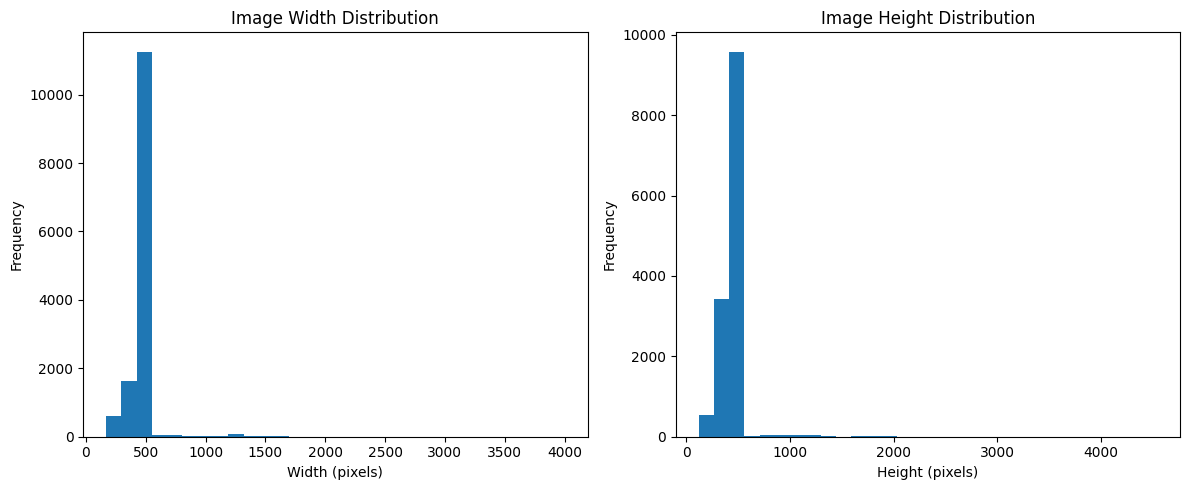

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# width distribution
plt.subplot(1, 2, 1)

plt.hist(
    sizes_df['width'],
    bins=30
)

plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')

# height distribution
plt.subplot(1, 2, 2)

plt.hist(
    sizes_df['height'],
    bins=30
)

plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

- Average pixel intensity per class (color analysis)

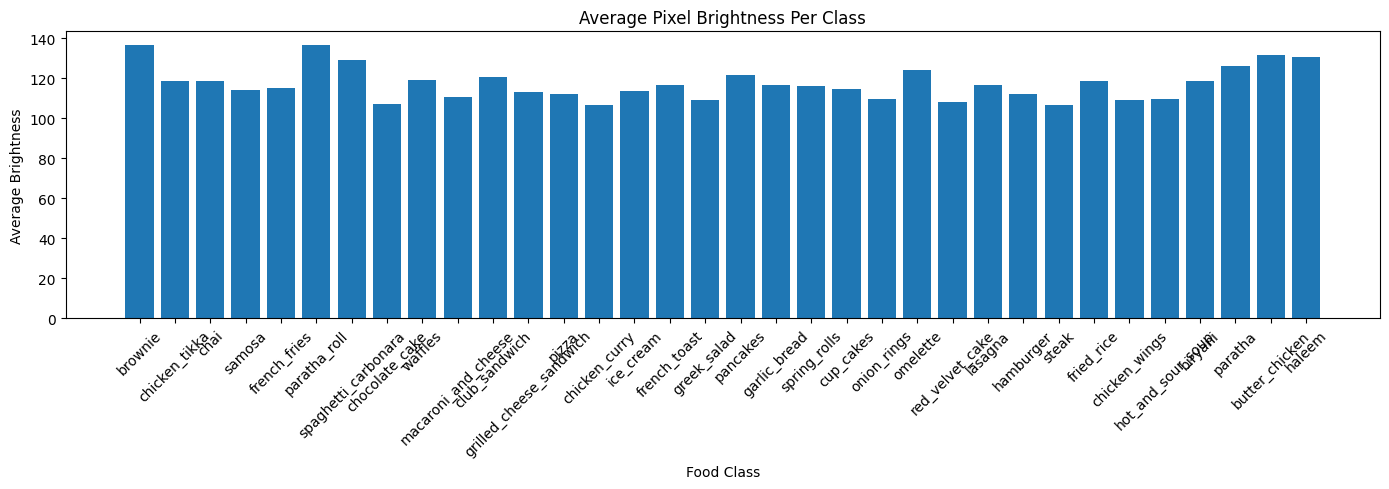

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

mean_brightness = {}

for cls in SELECTED_CLASSES:

    folder = os.path.join(OUTPUT_DIR, cls)

    if not os.path.exists(folder):
        continue

    # actual image files only
    images = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]

    if len(images) == 0:
        continue

    # random sample (max 50)
    sample_images = random.sample(
        images,
        min(50, len(images))
    )

    brightness_values = []

    for fname in sample_images:

        fpath = os.path.join(folder, fname)

        try:
            img = Image.open(fpath).convert('RGB')

            img_array = np.array(img)

            brightness_values.append(img_array.mean())

        except:
            pass

    # average brightness for class
    mean_brightness[cls] = np.mean(brightness_values)

# visualization
plt.figure(figsize=(14, 5))

bars = plt.bar(
    mean_brightness.keys(),
    mean_brightness.values()
)

plt.title('Average Pixel Brightness Per Class')
plt.xlabel('Food Class')
plt.ylabel('Average Brightness')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 5: Preprocessing and Data Generators

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# data augmentation + preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,

    width_shift_range=0.1,
    height_shift_range=0.1,

    validation_split=0.2
)

# training generator
train_gen = train_datagen.flow_from_directory(
    OUTPUT_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True,

    seed=SEED
)

# validation generator
val_gen = train_datagen.flow_from_directory(
    OUTPUT_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False,

    seed=SEED
)

# class mappings
print("\nClass Indices:")
print(train_gen.class_indices)

# dataset info
print(f"\nTraining Samples: {train_gen.samples}")
print(f"Validation Samples: {val_gen.samples}")

Found 11040 images belonging to 34 classes.
Found 2760 images belonging to 34 classes.

Class Indices:
{'biryani': 0, 'brownie': 1, 'butter_chicken': 2, 'chai': 3, 'chicken_curry': 4, 'chicken_tikka': 5, 'chicken_wings': 6, 'chocolate_cake': 7, 'club_sandwich': 8, 'cup_cakes': 9, 'french_fries': 10, 'french_toast': 11, 'fried_rice': 12, 'garlic_bread': 13, 'greek_salad': 14, 'grilled_cheese_sandwich': 15, 'haleem': 16, 'hamburger': 17, 'hot_and_sour_soup': 18, 'ice_cream': 19, 'lasagna': 20, 'macaroni_and_cheese': 21, 'omelette': 22, 'onion_rings': 23, 'pancakes': 24, 'paratha': 25, 'paratha_roll': 26, 'pizza': 27, 'red_velvet_cake': 28, 'samosa': 29, 'spaghetti_carbonara': 30, 'spring_rolls': 31, 'steak': 32, 'waffles': 33}

Training Samples: 11040
Validation Samples: 2760


## Step 6: Model building with our custom layer

In [21]:
import tensorflow as tf
from tensorflow.keras import layers

# Custom Attention Layer
class ChannelAttention(layers.Layer):

    def __init__(self, reduction_ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)

        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):

        channels = input_shape[-1]

        # global pooling
        self.gap = layers.GlobalAveragePooling2D()

        # bottleneck dense layer
        self.dense1 = layers.Dense(
            channels // self.reduction_ratio,
            activation='relu'
        )

        # attention weights
        self.dense2 = layers.Dense(
            channels,
            activation='sigmoid'
        )

        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):

        x = self.gap(inputs)

        x = self.dense1(x)

        x = self.dense2(x)

        # reshape attention weights
        x = tf.reshape(
            x,
            (-1, 1, 1, inputs.shape[-1])
        )

        # apply attention
        return inputs * x

    def get_config(self):

        config = super(ChannelAttention, self).get_config()

        config.update({
            "reduction_ratio": self.reduction_ratio
        })

        return config

It helps the model focus on the most relevant color and texture features in a food image, which directly improves food classification accuracy.

In [22]:
SELECTED_CLASSES = sorted(os.listdir(OUTPUT_DIR))
NUM_CLASSES = len(SELECTED_CLASSES)
print(f"Total classes: {NUM_CLASSES}")
print(SELECTED_CLASSES)

Total classes: 34
['biryani', 'brownie', 'butter_chicken', 'chai', 'chicken_curry', 'chicken_tikka', 'chicken_wings', 'chocolate_cake', 'club_sandwich', 'cup_cakes', 'french_fries', 'french_toast', 'fried_rice', 'garlic_bread', 'greek_salad', 'grilled_cheese_sandwich', 'haleem', 'hamburger', 'hot_and_sour_soup', 'ice_cream', 'lasagna', 'macaroni_and_cheese', 'omelette', 'onion_rings', 'pancakes', 'paratha', 'paratha_roll', 'pizza', 'red_velvet_cake', 'samosa', 'spaghetti_carbonara', 'spring_rolls', 'steak', 'waffles']


## Step 7: Training

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

# number of output classes
NUM_CLASSES = len(SELECTED_CLASSES)

# pretrained MobileNetV2 base
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze pretrained layers
base_model.trainable = False

# model input
inputs = tf.keras.Input(shape=(224, 224, 3))

# feature extraction
x = base_model(inputs, training=False)

# custom attention layer
x = ChannelAttention()(x)

# pooling
x = layers.GlobalAveragePooling2D()(x)

# fully connected layers
x = layers.Dense(
    256,
    activation='relu'
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation='relu'
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

# output layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

# final model
model = models.Model(
    inputs,
    outputs,
    name="Food_Classification_Model"
)

# model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Food_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention               │ (None, 7, 7, 1280)     │       411,040 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,035,778 (11.58 MB)

 Trainable params: 777,026 (2.96 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [24]:
# compile model
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/models/best_food_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# training
history = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=20,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

# save final model
model.save("/content/drive/MyDrive/models/final_food_classifier.h5")
# save history
import json
with open('/content/drive/MyDrive/models/history_round1.json', 'w') as f:
    json.dump(history.history, f)

print("\nModel training completed. Model and history saved to Drive.")

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.3383 - loss: 2.5266
Epoch 1: val_accuracy improved from None to 0.63587, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 334s 889ms/step - accuracy: 0.4609 - loss: 1.9691 - val_accuracy: 0.6359 - val_loss: 1.3047 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.6117 - loss: 1.3456
Epoch 2: val_accuracy improved from 0.63587 to 0.67319, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 288s 836ms/step - accuracy: 0.6098 - loss: 1.3429 - val_accuracy: 0.6732 - val_loss: 1.1452 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.6554 - loss: 1.1723
Epoch 3: val_accuracy improved from 0.67319 to 0.68768, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 316s 917ms/step - accuracy: 0.6544 - loss: 1.1761 - val_accuracy: 0.6877 - val_loss: 1.0529 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6848 - loss: 1.0579
Epoch 4: val_accuracy improved from 0.68768 to 0.69203, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 304s 881ms/step - accuracy: 0.6777 - loss: 1.0897 - val_accuracy: 0.6920 - val_loss: 1.0542 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.7025 - loss: 0.9892
Epoch 5: val_accuracy improved from 0.69203 to 0.70725, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 244s 709ms/step - accuracy: 0.7057 - loss: 0.9930 - val_accuracy: 0.7072 - val_loss: 1.0239 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.7225 - loss: 0.9203
Epoch 6: val_accuracy improved from 0.70725 to 0.70942, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 249s 723ms/step - accuracy: 0.7170 - loss: 0.9449 - val_accuracy: 0.7094 - val_loss: 1.0231 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7384 - loss: 0.8720
Epoch 7: val_accuracy improved from 0.70942 to 0.72826, saving model to /content/drive/MyDrive/models/best_food_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 247s 717ms/step - accuracy: 0.7372 - loss: 0.8857 - val_accuracy: 0.7283 - val_loss: 0.9976 - learning_rate: 0.0010
Epoch 8/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.7409 - loss: 0.8462
Epoch 8: val_accuracy did not improve from 0.72826
345/345 ━━━━━━━━━━━━━━━━━━━━ 246s 714ms/step - accuracy: 0.7446 - loss: 0.8427 - val_accuracy: 0.7163 - val_loss: 1.0031 - learning_rate: 0.0010
Epoch 9/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7669 - loss: 0.7574
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_accuracy did not improve from 0.72826
345/345 ━━━━━━━━━━━━━━━━━━━━ 244s 707ms/step - accuracy: 0.7638 - loss: 0.7772 - val_accuracy: 0.7101 - val_loss: 1.0376 - learning_rate: 0.0010
Epoch 10/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7960 - loss: 0.6729
Epoch 10: val_accuracy improved from 


Epoch 10: finished saving model to /content/drive/MyDrive/models/best_food_model.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 240s 696ms/step - accuracy: 0.7952 - loss: 0.6744 - val_accuracy: 0.7308 - val_loss: 0.9949 - learning_rate: 5.0000e-04
Epoch 11/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8149 - loss: 0.6073
Epoch 11: val_accuracy did not improve from 0.73080
345/345 ━━━━━━━━━━━━━━━━━━━━ 247s 715ms/step - accuracy: 0.8142 - loss: 0.6200 - val_accuracy: 0.7297 - val_loss: 0.9955 - learning_rate: 5.0000e-04
Epoch 12/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8207 - loss: 0.5742
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 12: val_accuracy did not improve from 0.73080
345/345 ━━━━━━━━━━━━━━━━━━━━ 245s 710ms/step - accuracy: 0.8199 - loss: 0.5946 - val_accuracy: 0.7275 - val_loss: 1.0252 - learning_rate: 5.0000e-04
Epoch 13/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.8366 - loss: 0.5347
Epoch 13: val_accur


Model training completed. Model and history saved to Drive.


In [26]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/models/best_food_model.h5',
    custom_objects={'ChannelAttention': ChannelAttention}
)

base_model = model.layers[1]
base_model.trainable = True

# Unfreeze last 60 layers directly
for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/models/best_finetuned_v2.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
)

# save history
import json
with open('/content/drive/MyDrive/models/history_round2.json', 'w') as f:
    json.dump(history_finetune.history, f)
print("Fine-tune history saved to Drive")

Epoch 1/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.5105 - loss: 1.8605
Epoch 1: val_accuracy improved from None to 0.69819, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 291s 758ms/step - accuracy: 0.5457 - loss: 1.6761 - val_accuracy: 0.6982 - val_loss: 1.2372
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6245 - loss: 1.3195
Epoch 2: val_accuracy improved from 0.69819 to 0.71377, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 255s 739ms/step - accuracy: 0.6404 - loss: 1.2559 - val_accuracy: 0.7138 - val_loss: 1.1449
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6848 - loss: 1.0852
Epoch 3: val_accuracy did not improve from 0.71377
345/345 ━━━━━━━━━━━━━━━━━━━━ 255s 739ms/step - accuracy: 0.6865 - loss: 1.0710 - val_accuracy: 0.7109 - val_loss: 1.0802
Epoch 4/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.7155 - loss: 0.9591
Epoch 4: val_accuracy improved from 0.71377 to 0.73043, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 253s 734ms/step - accuracy: 0.7145 - loss: 0.9581 - val_accuracy: 0.7304 - val_loss: 1.0400
Epoch 5/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.7325 - loss: 0.8891
Epoch 5: val_accuracy did not improve from 0.73043
345/345 ━━━━━━━━━━━━━━━━━━━━ 254s 735ms/step - accuracy: 0.7390 - loss: 0.8726 - val_accuracy: 0.7192 - val_loss: 1.0253
Epoch 6/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.7437 - loss: 0.8351
Epoch 6: val_accuracy did not improve from 0.73043
345/345 ━━━━━━━━━━━━━━━━━━━━ 251s 727ms/step - accuracy: 0.7490 - loss: 0.8263 - val_accuracy: 0.7243 - val_loss: 0.9833
Epoch 7/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.7510 - loss: 0.8139
Epoch 7: val_accuracy did not improve from 0.73043
345/345 ━━━━━━━━━━━━━━━━━━━━ 248s 721ms/step - accuracy: 0.7567 - loss: 0.7942 - val_accuracy: 0.7304 - val_loss: 0.9692
Epoch 8/15
34


Epoch 9: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 254s 737ms/step - accuracy: 0.7840 - loss: 0.7110 - val_accuracy: 0.7384 - val_loss: 0.9557
Epoch 10/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8019 - loss: 0.6722
Epoch 10: val_accuracy improved from 0.73841 to 0.74022, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 10: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 260s 753ms/step - accuracy: 0.7988 - loss: 0.6801 - val_accuracy: 0.7402 - val_loss: 0.9336
Epoch 11/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7972 - loss: 0.6780
Epoch 11: val_accuracy improved from 0.74022 to 0.74457, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 11: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 253s 732ms/step - accuracy: 0.7998 - loss: 0.6652 - val_accuracy: 0.7446 - val_loss: 0.9178
Epoch 12/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.8165 - loss: 0.6266
Epoch 12: val_accuracy did not improve from 0.74457
345/345 ━━━━━━━━━━━━━━━━━━━━ 252s 730ms/step - accuracy: 0.8112 - loss: 0.6291 - val_accuracy: 0.7442 - val_loss: 0.9283
Epoch 13/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8208 - loss: 0.5927
Epoch 13: val_accuracy improved from 0.74457 to 0.75362, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 13: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 254s 737ms/step - accuracy: 0.8162 - loss: 0.6035 - val_accuracy: 0.7536 - val_loss: 0.8914
Epoch 14/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8186 - loss: 0.5979
Epoch 14: val_accuracy improved from 0.75362 to 0.76087, saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5



Epoch 14: finished saving model to /content/drive/MyDrive/models/best_finetuned_v2.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 255s 738ms/step - accuracy: 0.8196 - loss: 0.5900 - val_accuracy: 0.7609 - val_loss: 0.8854
Epoch 15/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.8227 - loss: 0.5714
Epoch 15: val_accuracy did not improve from 0.76087
345/345 ━━━━━━━━━━━━━━━━━━━━ 253s 733ms/step - accuracy: 0.8260 - loss: 0.5659 - val_accuracy: 0.7496 - val_loss: 0.8910
Fine-tune history saved to Drive


In [27]:
model = load_model(
    '/content/drive/MyDrive/models/best_finetuned_v2.h5',
    custom_objects={'ChannelAttention': ChannelAttention}
)

# keep same 60 unfrozen layers
base_model = model.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

# slightly lower lr than before
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft4 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/models/best_finetuned_v3.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
)

import json
with open('/content/drive/MyDrive/models/history_round3.json', 'w') as f:
    json.dump(history_ft4.history, f)
print("Round 3 saved to Drive")

Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8332 - loss: 0.5411
Epoch 1: val_accuracy improved from None to 0.75326, saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 289s 758ms/step - accuracy: 0.8277 - loss: 0.5589 - val_accuracy: 0.7533 - val_loss: 0.8876
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.8219 - loss: 0.5759
Epoch 2: val_accuracy improved from 0.75326 to 0.75906, saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 258s 748ms/step - accuracy: 0.8305 - loss: 0.5594 - val_accuracy: 0.7591 - val_loss: 0.8783
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.8354 - loss: 0.5586
Epoch 3: val_accuracy did not improve from 0.75906
345/345 ━━━━━━━━━━━━━━━━━━━━ 260s 755ms/step - accuracy: 0.8316 - loss: 0.5607 - val_accuracy: 0.7536 - val_loss: 0.8753
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8384 - loss: 0.5452
Epoch 4: val_accuracy improved from 0.75906 to 0.76486, saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/models/best_finetuned_v3.h5
345/345 ━━━━━━━━━━━━━━━━━━━━ 256s 743ms/step - accuracy: 0.8361 - loss: 0.5489 - val_accuracy: 0.7649 - val_loss: 0.8724
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8345 - loss: 0.5366
Epoch 5: val_accuracy did not improve from 0.76486
345/345 ━━━━━━━━━━━━━━━━━━━━ 290s 840ms/step - accuracy: 0.8355 - loss: 0.5378 - val_accuracy: 0.7551 - val_loss: 0.8743
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8413 - loss: 0.5232
Epoch 6: val_accuracy did not improve from 0.76486
345/345 ━━━━━━━━━━━━━━━━━━━━ 257s 745ms/step - accuracy: 0.8372 - loss: 0.5356 - val_accuracy: 0.7598 - val_loss: 0.8801
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8377 - loss: 0.5259
Epoch 7: val_accuracy did not improve from 0.76486
345/345 ━━━━━━━━━━━━━━━━━━━━ 260s 754ms/step - accuracy: 0.8338 - loss: 0.5432 - val_accuracy: 0.7627 - val_loss: 0.8711
Epoch 8/10
34

## Step 8: Results and Visualizations

- Loss and accuracy curves

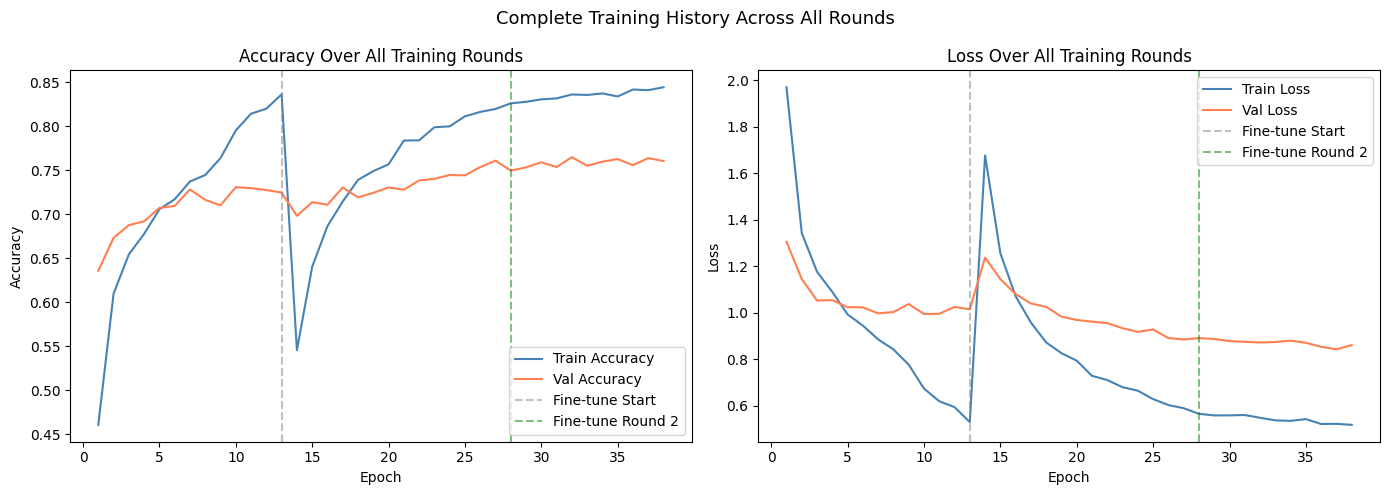

In [28]:
with open('/content/drive/MyDrive/models/history_round1.json', 'r') as f:
    h1 = json.load(f)
with open('/content/drive/MyDrive/models/history_round2.json', 'r') as f:
    h2 = json.load(f)
with open('/content/drive/MyDrive/models/history_round3.json', 'r') as f:
    h3 = json.load(f)

all_train_acc = h1['accuracy'] + h2['accuracy'] + h3['accuracy']
all_val_acc = h1['val_accuracy'] + h2['val_accuracy'] + h3['val_accuracy']
all_train_loss = h1['loss'] + h2['loss'] + h3['loss']
all_val_loss = h1['val_loss'] + h2['val_loss'] + h3['val_loss']

split1 = len(h1['accuracy'])
split2 = split1 + len(h2['accuracy'])
epochs_range = range(1, len(all_train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, all_train_acc, label='Train Accuracy', color='steelblue')
axes[0].plot(epochs_range, all_val_acc, label='Val Accuracy', color='coral')
axes[0].axvline(x=split1, color='gray', linestyle='--', alpha=0.5, label='Fine-tune Start')
axes[0].axvline(x=split2, color='green', linestyle='--', alpha=0.5, label='Fine-tune Round 2')
axes[0].set_title('Accuracy Over All Training Rounds')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, all_train_loss, label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, all_val_loss, label='Val Loss', color='coral')
axes[1].axvline(x=split1, color='gray', linestyle='--', alpha=0.5, label='Fine-tune Start')
axes[1].axvline(x=split2, color='green', linestyle='--', alpha=0.5, label='Fine-tune Round 2')
axes[1].set_title('Loss Over All Training Rounds')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Complete Training History Across All Rounds', fontsize=13)
plt.tight_layout()
plt.show()

- Confusion matrix

Found 2760 images belonging to 34 classes.
87/87 ━━━━━━━━━━━━━━━━━━━━ 28s 264ms/step


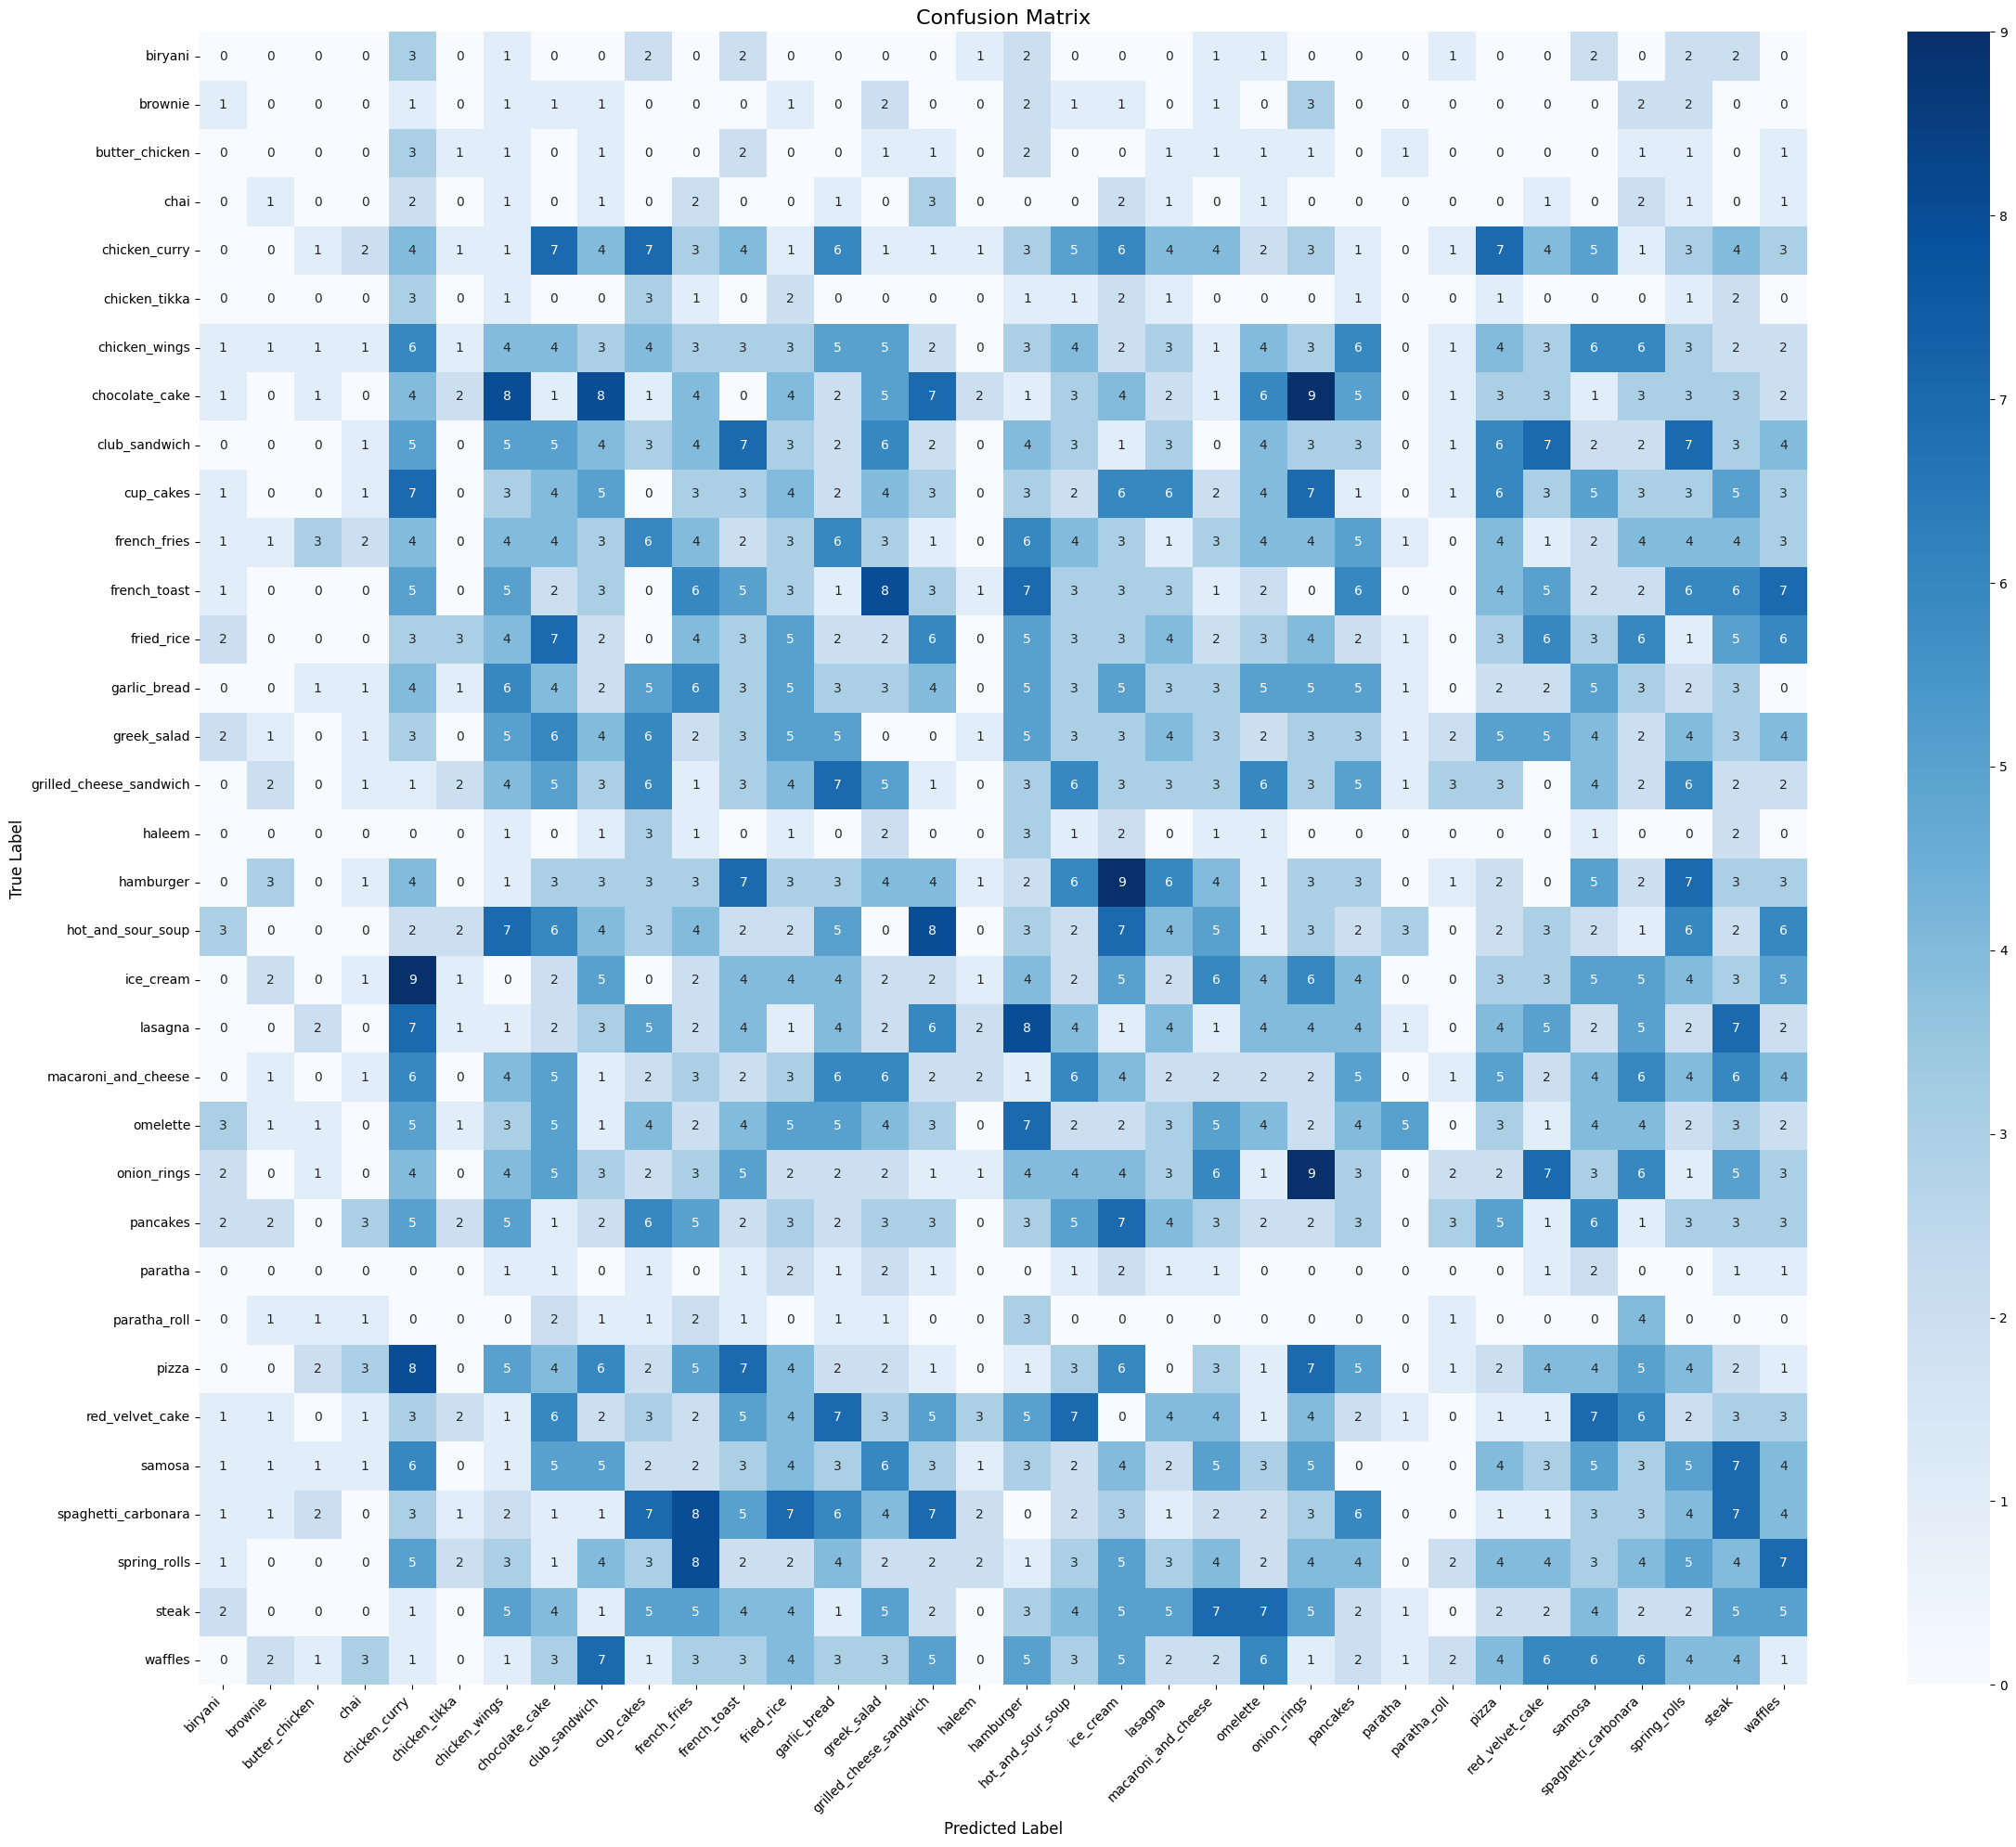

In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf

class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(channels // self.reduction_ratio, activation='relu')
        self.dense2 = tf.keras.layers.Dense(channels, activation='sigmoid')
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = tf.reshape(x, (-1, 1, 1, inputs.shape[-1]))
        return inputs * x

    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

model = load_model(
    '/content/drive/MyDrive/models/best_finetuned_v3.h5',
    custom_objects={'ChannelAttention': ChannelAttention}
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_gen = eval_datagen.flow_from_directory(
    OUTPUT_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

class_names = list(val_gen.class_indices.keys())

# reset and predict
val_gen.reset()
predictions = model.predict(val_gen, verbose=1)
pred_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(24, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Classification report

In [30]:
# classification report
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))


Classification Report:

                         precision    recall  f1-score   support

                biryani       0.65      0.85      0.74        20
                brownie       0.90      0.95      0.93        20
         butter_chicken       0.72      0.65      0.68        20
                   chai       0.80      1.00      0.89        20
          chicken_curry       0.61      0.77      0.68       100
          chicken_tikka       0.74      0.85      0.79        20
          chicken_wings       0.81      0.80      0.80       100
         chocolate_cake       0.71      0.75      0.73       100
          club_sandwich       0.79      0.74      0.76       100
              cup_cakes       0.82      0.79      0.81       100
           french_fries       0.87      0.90      0.89       100
           french_toast       0.65      0.66      0.66       100
             fried_rice       0.83      0.81      0.82       100
           garlic_bread       0.70      0.71      0.71       100

## Sample predictions with images

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# reset generator
val_gen.reset()

# get a batch
batch_images, batch_labels = next(val_gen)

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i in range(20):

    img = batch_images[i]

    # true label
    true_label = class_names[np.argmax(batch_labels[i])]

    # prediction
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label = class_names[np.argmax(pred)]

    # correct denormalization for MobileNetV2 preprocess_input
    display_img = img.copy()
    display_img /= 2.0
    display_img += 0.5
    display_img = np.clip(display_img, 0, 1)

    # display image
    axes[i].imshow(display_img)

    color = 'green' if true_label == pred_label else 'red'

    axes[i].set_title(
        f"T: {true_label}\nP: {pred_label}",
        color=color,
        fontsize=9
    )

    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.